# Solution for Lab 0, Question 1

After reading the problem statement we can begin by reading in the data.
For this we will be using pd.read_csv()

In [51]:
import pandas as pd

In [52]:
df = pd.read_csv('tree_survey_data.csv')

# First steps


So the first thing you should do after loading a dataset in my opinion is to run df.head to just have a look at how the data looks

## Data Cleaning
Let us begin by trying to clean the problematic values in the dataset.


In [53]:
df.head()

,Surveyor,Latitude,Longitude,Tree Height,Tree Trunk Thickness,Tree Leaf Size,Left Sub Leaf Size,Right Sub Leaf Size,Middle Sub Leaf Size
0,Bob,13.0,77.6,284.50,441.70,145.50,48.10,48.30,47.90
1,Alice,13.1,80.3,29.16,49.38,23.64,7.82,7.82,7.77
2,Alice,11.0,77.0,21.55,42.23,39.64,13.19,13.23,13.21
3,Bob,13.0,77.6,295.80,522.50,177.30,60.70,60.70,61.40
4,Bob,11.0,76.9,319.30,474.10,393.80,132.50,133.10,133.30


In [54]:
df.head(40) # To show more rows

,Surveyor,Latitude,Longitude,Tree Height,Tree Trunk Thickness,Tree Leaf Size,Left Sub Leaf Size,Right Sub Leaf Size,Middle Sub Leaf Size
0,Bob,13.0,77.6,284.500000,4.417000e+02,1.455000e+02,4.810000e+01,4.830000e+01,4.790000e+01
1,Alice,13.1,80.3,29.160000,4.938000e+01,2.364000e+01,7.820000e+00,7.820000e+00,7.770000e+00
2,Alice,11.0,77.0,21.550000,4.223000e+01,3.964000e+01,1.319000e+01,1.323000e+01,1.321000e+01
3,Bob,13.0,77.6,295.800000,5.225000e+02,1.773000e+02,6.070000e+01,6.070000e+01,6.140000e+01
4,Bob,11.0,76.9,319.300000,4.741000e+02,3.938000e+02,1.325000e+02,1.331000e+02,1.333000e+02
5,Alice,12.9,77.6,29.110000,4.903000e+01,1.329000e+01,4.540000e+00,4.560000e+00,4.590000e+00
6,Charlie,-187.4,-197.2,999448.883760,2.096861e+02,9.999330e+05,3.527590e+02,5.487005e+02,1.000179e+06
7,Bob,11.0,77.0,300.700000,4.938000e+02,3.938000e+02,1.306000e+02,1.310000e+02,1.308000e+02
8,Alice,11.0,76.9,42.190000,6.108000e+01,3.261000e+01,1.083000e+01,1.078000e+01,1.081000e+01
9,Alice,11.0,76.9,22.880000,4.525000e+01,3.832000e+01,1.281000e+01,1.277000e+01,1.279000e+01


Already I see some interesting patterns in the data..... but a few more commands for a broad overview

In [55]:
df.describe()

,Latitude,Longitude,Tree Height,Tree Trunk Thickness,Tree Leaf Size,Left Sub Leaf Size,Right Sub Leaf Size,Middle Sub Leaf Size
count,1010.00000,1010.000000,9.510000e+02,9.560000e+02,9.630000e+02,9.680000e+02,9.690000e+02,9.540000e+02
mean,10.46802,64.983663,5.055235e+04,6.085137e+04,6.030482e+04,4.749727e+04,5.364310e+04,6.078830e+04
std,55.57346,101.895892,2.189660e+05,2.388328e+05,2.380538e+05,2.128594e+05,2.254715e+05,2.390977e+05
min,-198.20000,-389.100000,-2.564974e+03,-3.458169e+03,-3.061405e+03,-2.892034e+03,-2.973306e+03,-4.375579e+03
25%,11.00000,77.000000,2.947500e+01,4.901000e+01,2.183500e+01,7.142500e+00,6.940000e+00,7.710000e+00
50%,12.90000,77.600000,2.043000e+02,4.035000e+02,1.165000e+02,3.595000e+01,3.270000e+01,3.965000e+01
75%,13.00000,77.600000,3.160500e+02,5.161000e+02,3.398500e+02,1.136500e+02,1.135000e+02,1.143000e+02
max,198.30000,395.800000,1.001305e+06,1.002503e+06,1.002060e+06,1.001300e+06,1.001851e+06,1.002360e+06


In [56]:
df.isna().sum() # Raw number of nans

Surveyor                 0
Latitude                 0
Longitude                0
Tree Height             59
Tree Trunk Thickness    54
Tree Leaf Size          47
Left Sub Leaf Size      42
Right Sub Leaf Size     41
Middle Sub Leaf Size    56
dtype: int64

In [57]:
df.isna().mean() # Percentage nans

Surveyor                0.000000
Latitude                0.000000
Longitude               0.000000
Tree Height             0.058416
Tree Trunk Thickness    0.053465
Tree Leaf Size          0.046535
Left Sub Leaf Size      0.041584
Right Sub Leaf Size     0.040594
Middle Sub Leaf Size    0.055446
dtype: float64

In [58]:
# Showing the rows with at least one nan

df[df.isna().any(axis=1)]

,Surveyor,Latitude,Longitude,Tree Height,Tree Trunk Thickness,Tree Leaf Size,Left Sub Leaf Size,Right Sub Leaf Size,Middle Sub Leaf Size
19,Charlie,-166.4,308.2,-1.591876e+03,NaN,1.001686e+06,1.001131e+06,9.993599e+05,NaN
26,Charlie,187.6,-290.3,-1.806510e+03,9.993035e+05,-1.271730e+03,NaN,6.352455e+02,-1.353653e+03
34,Charlie,-184.0,42.4,-2.534125e+03,-9.108018e+02,9.999214e+05,-5.054472e+02,NaN,NaN
37,Charlie,-144.8,219.2,NaN,9.995542e+05,-1.482229e+02,-7.259612e+02,NaN,1.000033e+06
39,Charlie,-168.1,-233.1,NaN,-1.728390e+03,9.997378e+05,NaN,-2.783103e+02,-9.913344e+02
...,...,...,...,...,...,...,...,...,...
994,Charlie,116.0,-280.7,-9.760200e+02,1.000851e+06,4.457599e+02,NaN,NaN,1.001346e+06
999,Charlie,-80.7,386.0,1.000572e+06,1.000504e+06,1.000252e+06,1.346397e+02,NaN,1.002269e+06
1000,Charlie,-104.5,-215.1,-6.115754e+02,-5.740890e+02,NaN,NaN,-3.390883e+02,1.000330e+06
1003,Charlie,-164.7,155.2,3.353173e+02,9.989602e+05,5.382116e+02,NaN,-1.070321e+03,NaN


So now it should be obvious what We observed earlier....
All the nan rows have the surveyor as charlie...
So let us try to look at the data of charlie

In [59]:
df[df['Surveyor'] == "Charlie"].head(50)

,Surveyor,Latitude,Longitude,Tree Height,Tree Trunk Thickness,Tree Leaf Size,Left Sub Leaf Size,Right Sub Leaf Size,Middle Sub Leaf Size
6,Charlie,-187.4,-197.2,9.994489e+05,2.096861e+02,9.999330e+05,3.527590e+02,5.487005e+02,1.000179e+06
12,Charlie,-114.9,-311.8,1.334506e+03,-1.149741e+03,-7.825941e+02,-7.064755e+02,1.000195e+06,9.994263e+05
16,Charlie,-132.2,268.9,1.206857e+02,1.000201e+06,5.790763e+02,1.000178e+06,-7.755800e+02,9.998560e+05
19,Charlie,-166.4,308.2,-1.591876e+03,NaN,1.001686e+06,1.001131e+06,9.993599e+05,NaN
26,Charlie,187.6,-290.3,-1.806510e+03,9.993035e+05,-1.271730e+03,NaN,6.352455e+02,-1.353653e+03
30,Charlie,34.4,-116.0,-8.120582e+02,-5.436657e+01,1.002060e+06,9.998908e+05,-8.447030e+02,1.002360e+06
34,Charlie,-184.0,42.4,-2.534125e+03,-9.108018e+02,9.999214e+05,-5.054472e+02,NaN,NaN
37,Charlie,-144.8,219.2,NaN,9.995542e+05,-1.482229e+02,-7.259612e+02,NaN,1.000033e+06
39,Charlie,-168.1,-233.1,NaN,-1.728390e+03,9.997378e+05,NaN,-2.783103e+02,-9.913344e+02
45,Charlie,-142.7,19.9,1.000542e+06,1.000662e+06,1.000346e+06,NaN,-1.282125e+03,1.060800e+03


So all charlie values are nonsensical in my opinion... negative lengths nans very large and very small values....

Looking at such data in real life you would probably assume that it is faulty so it is best to drop it.

In [60]:
# So now we will just drop all the charlie rows
df = df.drop(df[df['Surveyor'] == "Charlie"].index)
df.head()

In [63]:
df.head(30)

,Surveyor,Latitude,Longitude,Tree Height,Tree Trunk Thickness,Tree Leaf Size,Left Sub Leaf Size,Right Sub Leaf Size,Middle Sub Leaf Size
0,Bob,13.0,77.6,284.50,441.70,145.50,48.10,48.30,47.90
1,Alice,13.1,80.3,29.16,49.38,23.64,7.82,7.82,7.77
2,Alice,11.0,77.0,21.55,42.23,39.64,13.19,13.23,13.21
3,Bob,13.0,77.6,295.80,522.50,177.30,60.70,60.70,61.40
4,Bob,11.0,76.9,319.30,474.10,393.80,132.50,133.10,133.30
5,Alice,12.9,77.6,29.11,49.03,13.29,4.54,4.56,4.59
7,Bob,11.0,77.0,300.70,493.80,393.80,130.60,131.00,130.80
8,Alice,11.0,76.9,42.19,61.08,32.61,10.83,10.78,10.81
9,Alice,11.0,76.9,22.88,45.25,38.32,12.81,12.77,12.79
10,Alice,12.9,77.6,31.63,52.55,16.78,5.68,5.61,5.72


Even here I see quite a clear pattern.... The values of alice and bob seem to be off by a factor of 10....
But let us investigate it further.
It naturally leads us to our next step

## Data Normalization

For this we will split the dataframe into an alice and a bob dataframe 

In [64]:
df_alice = df[df['Surveyor'] == "Alice"]
df_bob = df[df['Surveyor'] == "Bob"]


df_alice.describe()

,Latitude,Longitude,Tree Height,Tree Trunk Thickness,Tree Leaf Size,Left Sub Leaf Size,Right Sub Leaf Size,Middle Sub Leaf Size
count,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000
mean,12.283846,77.953333,30.186436,50.136974,26.362667,8.787641,8.790256,8.788308
std,0.964629,1.267825,5.043012,4.949416,11.122948,3.714244,3.713446,3.717144
min,10.900000,76.900000,15.890000,33.380000,6.490000,2.020000,2.030000,2.040000
25%,11.000000,77.000000,26.750000,46.845000,15.680000,5.260000,5.295000,5.250000
50%,13.000000,77.600000,30.145000,49.785000,25.635000,8.545000,8.550000,8.565000
75%,13.000000,77.600000,33.570000,53.387500,36.962500,12.270000,12.282500,12.267500
max,13.200000,80.400000,44.020000,65.300000,48.540000,16.090000,16.010000,16.100000


In [65]:
df_bob.describe()

,Latitude,Longitude,Tree Height,Tree Trunk Thickness,Tree Leaf Size,Left Sub Leaf Size,Right Sub Leaf Size,Middle Sub Leaf Size
count,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000
mean,12.179087,77.809135,302.988702,502.165865,267.455529,89.090385,89.108654,89.112019
std,0.988839,1.186597,50.484427,51.051521,113.087069,37.685971,37.677536,37.688625
min,10.900000,76.900000,116.100000,365.300000,59.200000,20.500000,20.300000,20.000000
25%,11.000000,77.000000,269.075000,465.300000,157.825000,52.550000,52.675000,52.600000
50%,12.900000,77.600000,302.800000,504.500000,260.550000,86.400000,86.150000,86.450000
75%,13.000000,77.600000,337.100000,536.375000,378.425000,125.725000,125.800000,125.850000
max,13.200000,80.300000,421.900000,656.400000,478.900000,161.600000,161.700000,160.900000


<Axes: >

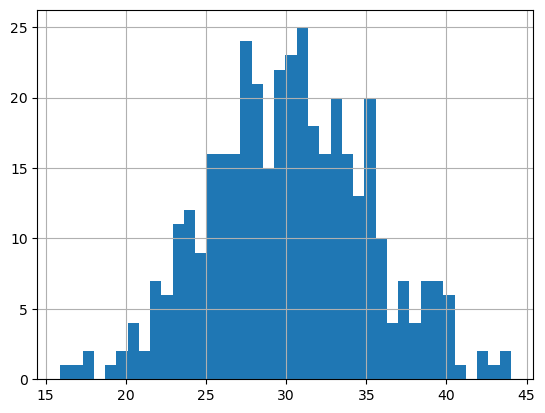

In [66]:
df_alice["Tree Height"].hist(bins=40)

<Axes: ylabel='Frequency'>

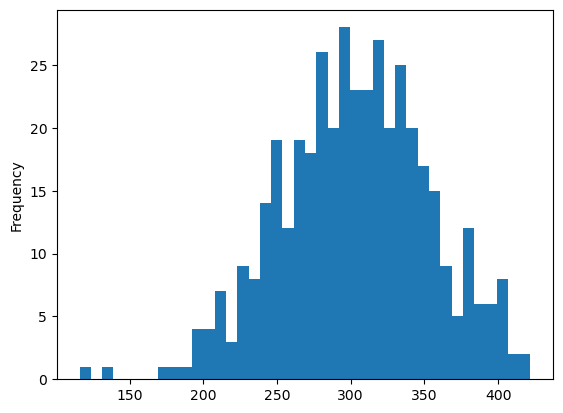

In [67]:
df_bob["Tree Height"].plot.hist(bins=40)

So the above two seem very similar in distribution as well....

So to normalise I will just multiply all the alice rows by 10

In [68]:
df.head()

,Surveyor,Latitude,Longitude,Tree Height,Tree Trunk Thickness,Tree Leaf Size,Left Sub Leaf Size,Right Sub Leaf Size,Middle Sub Leaf Size
0,Bob,13.0,77.6,284.50,441.70,145.50,48.10,48.30,47.90
1,Alice,13.1,80.3,29.16,49.38,23.64,7.82,7.82,7.77
2,Alice,11.0,77.0,21.55,42.23,39.64,13.19,13.23,13.21
3,Bob,13.0,77.6,295.80,522.50,177.30,60.70,60.70,61.40
4,Bob,11.0,76.9,319.30,474.10,393.80,132.50,133.10,133.30


In [69]:
num_columns = ["Tree Height", "Tree Trunk Thickness", "Tree Leaf Size", "Left Sub Leaf Size", "Right Sub Leaf Size", "Middle Sub Leaf Size"]

In [70]:
df.loc[df["Surveyor"] == "Alice", num_columns] = df.loc[df["Surveyor"] == "Alice", num_columns] * 10

In [71]:
df.head()

,Surveyor,Latitude,Longitude,Tree Height,Tree Trunk Thickness,Tree Leaf Size,Left Sub Leaf Size,Right Sub Leaf Size,Middle Sub Leaf Size
0,Bob,13.0,77.6,284.5,441.7,145.5,48.1,48.3,47.9
1,Alice,13.1,80.3,291.6,493.8,236.4,78.2,78.2,77.7
2,Alice,11.0,77.0,215.5,422.3,396.4,131.9,132.3,132.1
3,Bob,13.0,77.6,295.8,522.5,177.3,60.7,60.7,61.4
4,Bob,11.0,76.9,319.3,474.1,393.8,132.5,133.1,133.3


Now I think we have finally gotten the data into a mutually comparable form So we Can start looking for relationships between the different quantities.

# Analysis of Relationships


## Distribution of Columns

<Axes: >

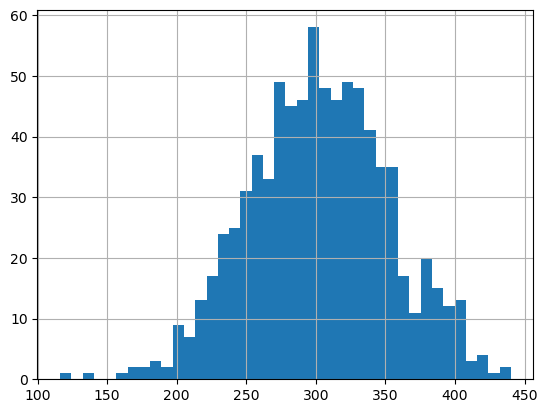

In [80]:
df["Tree Height"].hist(bins=40)

<Axes: >

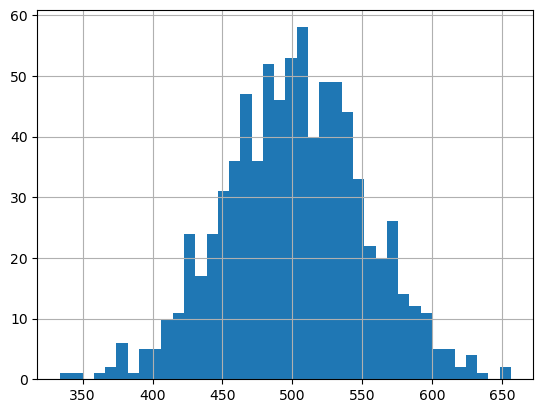

In [81]:
df["Tree Trunk Thickness"].hist(bins=40)

<Axes: >

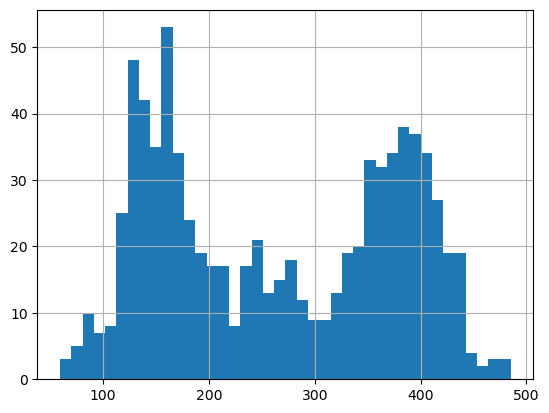

In [82]:
df["Tree Leaf Size"].hist(bins=40)

Looking at the histogram..... the first two are gaussian but the third one is quite interesting. It looks like it comes from maybe a combination of three distributions.

## Relationship between Columns

<Axes: xlabel='Tree Trunk Thickness', ylabel='Tree Height'>

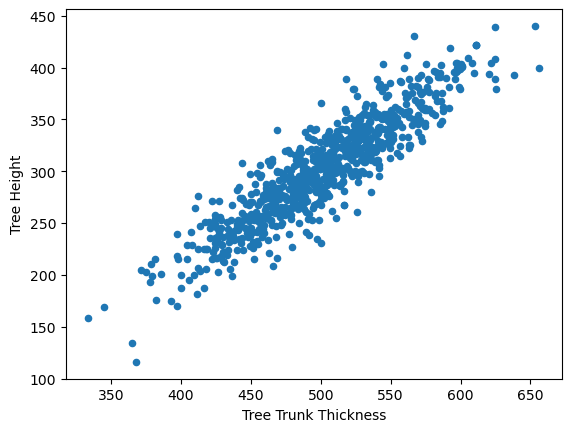

In [72]:
df.plot.scatter(y='Tree Height', x="Tree Trunk Thickness")

So the Tree Height and Tree Trunk Thickness are very strongly correlated

In [73]:
# So to help with coloring we will add a categorical column for the surveyor with numbers

df["Surveyor_code"] = df["Surveyor"].astype("category").cat.codes

<Axes: xlabel='Tree Height', ylabel='Tree Trunk Thickness'>

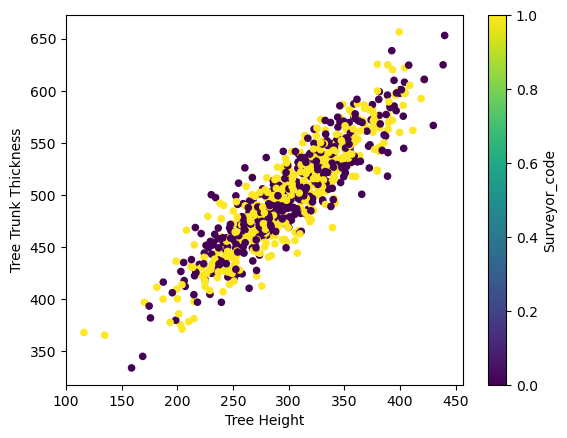

In [74]:
df.plot.scatter(x="Tree Height", y="Tree Trunk Thickness", c="Surveyor_code", colormap="viridis")

<Axes: xlabel='Tree Height', ylabel='Tree Leaf Size'>

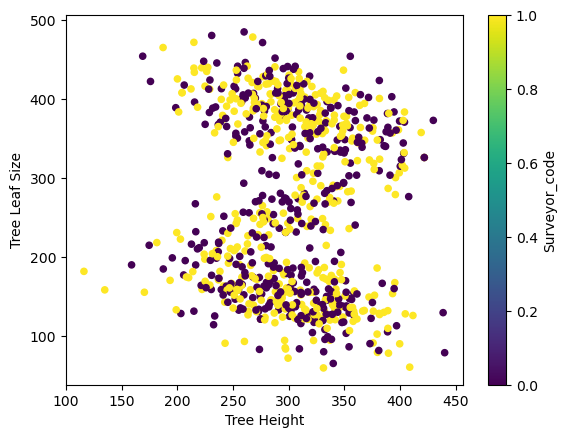

In [77]:
df.plot.scatter(x="Tree Height", y = "Tree Leaf Size", c="Surveyor_code", colormap="viridis")

Here the pattern does not seem too clear as of now

<Axes: xlabel='Tree Trunk Thickness', ylabel='Tree Leaf Size'>

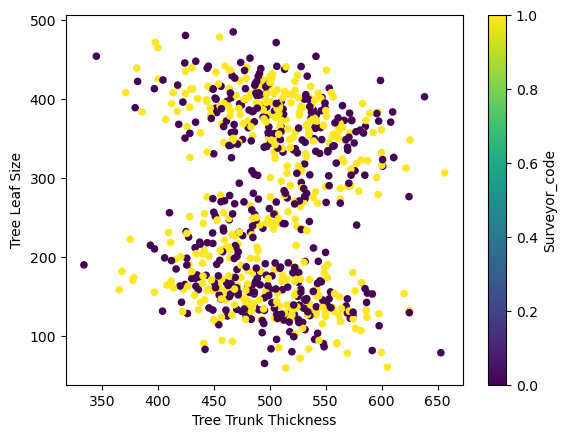

In [78]:
df.plot.scatter(x="Tree Trunk Thickness", y="Tree Leaf Size", c="Surveyor_code", colormap="viridis")

## Adding Location Information


Now let us investigate the location based columns

<Axes: xlabel='Latitude', ylabel='Longitude'>

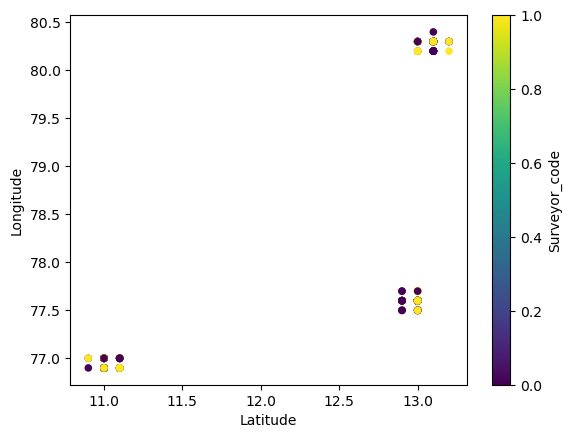

In [75]:
df.plot.scatter(y="Longitude", x='Latitude', c="Surveyor_code", colormap="viridis")

So there seem to be three locations we are working in and it may be interesting to treat them differently

In [84]:
# Location as A if latitude < 12, B if longitude > 79 and C otherwise

df["Location"] = "C"
df.loc[df["Latitude"] < 12, "Location"] = "A"
df.loc[df["Longitude"] > 79, "Location"] = "B"

In [85]:
# To help with colouring also add a location code column


df["Location_code"] = df["Location"].astype("category").cat.codes   

Let us make the above plots again but with the location as a colour

<Axes: xlabel='Tree Trunk Thickness', ylabel='Tree Height'>

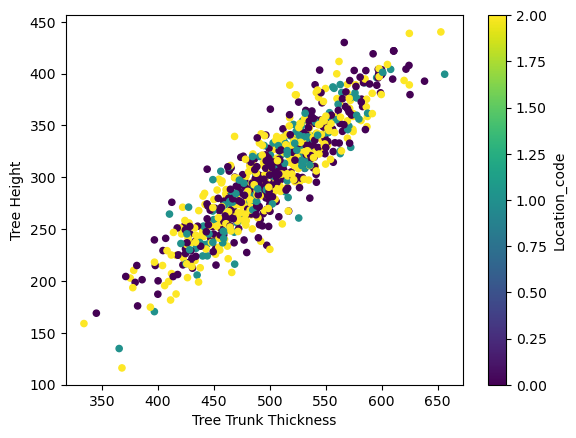

In [86]:
df.plot.scatter(x="Tree Trunk Thickness", y="Tree Height", c="Location_code", colormap="viridis")

<Axes: xlabel='Tree Trunk Thickness', ylabel='Tree Leaf Size'>

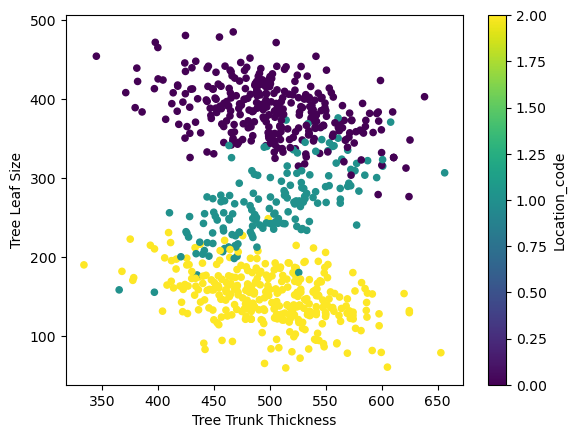

In [87]:
df.plot.scatter(x="Tree Trunk Thickness", y="Tree Leaf Size", c="Location_code", colormap="viridis")

<Axes: xlabel='Tree Height', ylabel='Tree Leaf Size'>

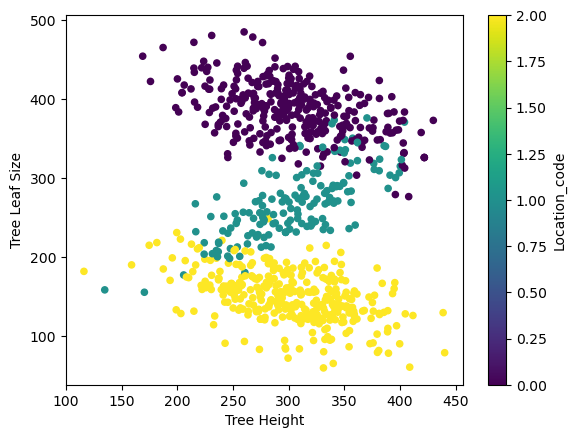

In [89]:
df.plot.scatter(x="Tree Height", y = "Tree Leaf Size", c="Location_code", colormap="viridis")

So from the above histogram it is quite clear that the tree leaf size depends on height (and thickness) differently depending on the location.
In two of the location it decreaces with height yet in one of the locations it actually increaces with height

Now let us also try and see the relationship between tree leaf size and the sub leaf sizes.


I have a strong prior that all of them are one third the leaf size so let us test that first

<Axes: ylabel='Frequency'>

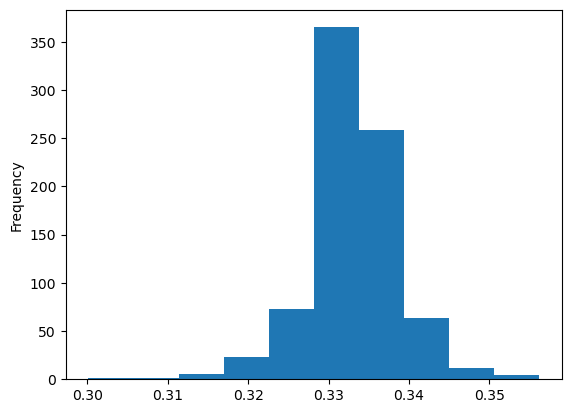

In [90]:
ratio_l = df["Left Sub Leaf Size"] / df["Tree Leaf Size"]
ratio_r = df["Right Sub Leaf Size"] / df["Tree Leaf Size"]
ratio_m = df["Middle Sub Leaf Size"] / df["Tree Leaf Size"]


ratio_l.plot.hist()

<Axes: ylabel='Frequency'>

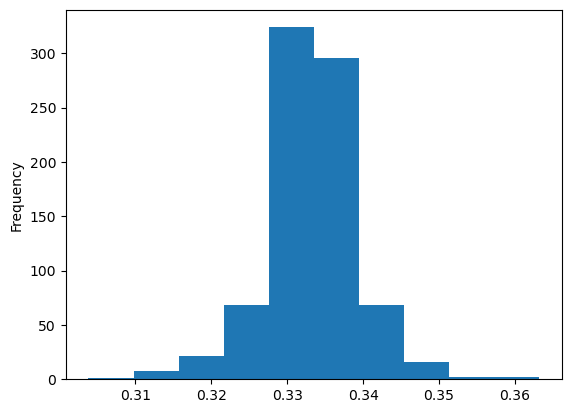

In [91]:
ratio_r.plot.hist()

<Axes: ylabel='Frequency'>

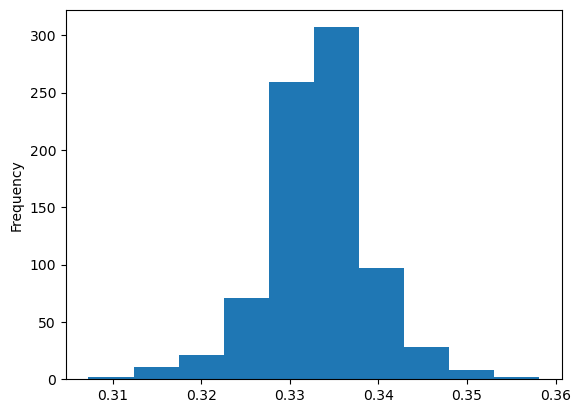

In [92]:
ratio_m.plot.hist()

All of the above are actually quite close to 0.33 so that means our hypothesis is roughly correct


You guys can try to investigate a bit about left, right and middle tree leaf size against thickness, location and height but I will skip that here. (There might be something interesting there maybe... Try to have a look)

# The Final Question

If you struggled withe the previous parts of the lab then don't worry. It was probably because you guys were using pandas for the first time and are not familiar with data analysis at this moment.
It will definitely become easier to think about with time.

This question on the other hand is something that I think is genuinely a bit difficult. And I was very happy to see so many different ways people solved it.

So I will outline one of the solution methods here. I have also described two others .But if you have any other way to solve it I'd love to have a look at it as well.

## Sol 1

We can think that leaf X grows first and then Y and Z copy it

So it would be reasonable to model


$$Y = X + \sigma_{1}$$

$$Z = X + \sigma_{2}$$

Where $\sigma_{1}$ and $\sigma_{2}$ is independent gaussian noise


So now



$$X - Y = \sigma_{1} 	\sim \mathcal{N}(0, \sigma)$$

$$Z - X = \sigma_{2} 	\sim \mathcal{N}(0, \sigma)$$


$$Y - Z = \sigma_{1} - \sigma_{2} 	\sim \mathcal{N}(0, 2 \sigma)$$

So the difference of the two leaves that are not the original will have a greater standard deviation

<Axes: ylabel='Frequency'>

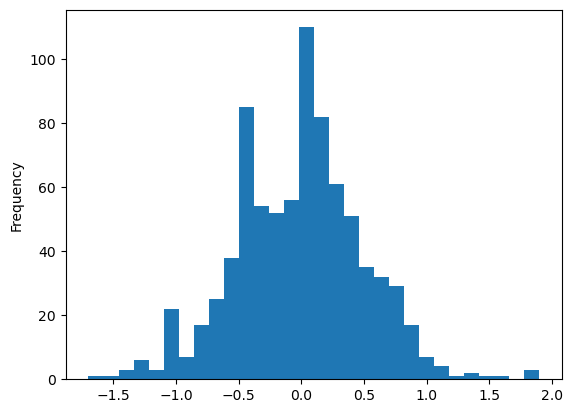

In [93]:
diff_1 = df["Left Sub Leaf Size"] - df["Right Sub Leaf Size"]
diff_1.plot.hist(bins=30)

<Axes: ylabel='Frequency'>

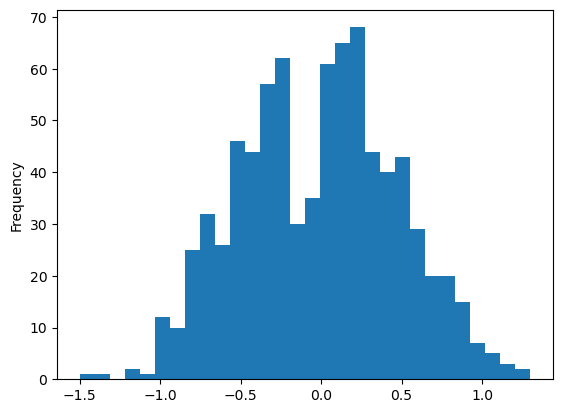

In [94]:
diff_2 = df["Left Sub Leaf Size"] - df["Middle Sub Leaf Size"]
diff_2.plot.hist(bins=30)

<Axes: ylabel='Frequency'>

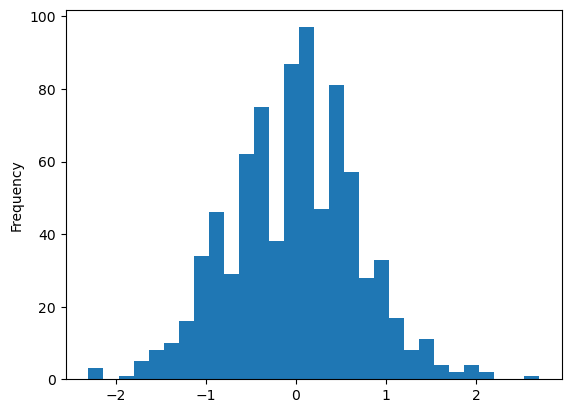

In [95]:
diff_3 = df["Middle Sub Leaf Size"] - df["Right Sub Leaf Size"]
diff_3.plot.hist(bins=30)

Since the third distribution very clearly has a greater standard deviation the left leaf will be the original 

# Alternative solution methods

Some that I saw


If you think about it for a bit... The chances of the original being "In the middle" is actually greater than one third. (If you assume the noise is as likely to be positive as it is to be negative). This is not a general solution method (Unlike the other two) because it does assume something about the distribution that may not be true.




Another solution that is even more robust would be to check the fact that


X - Y is independent to X - Z


Here we do not make any assumptions about the distribution of the noise either